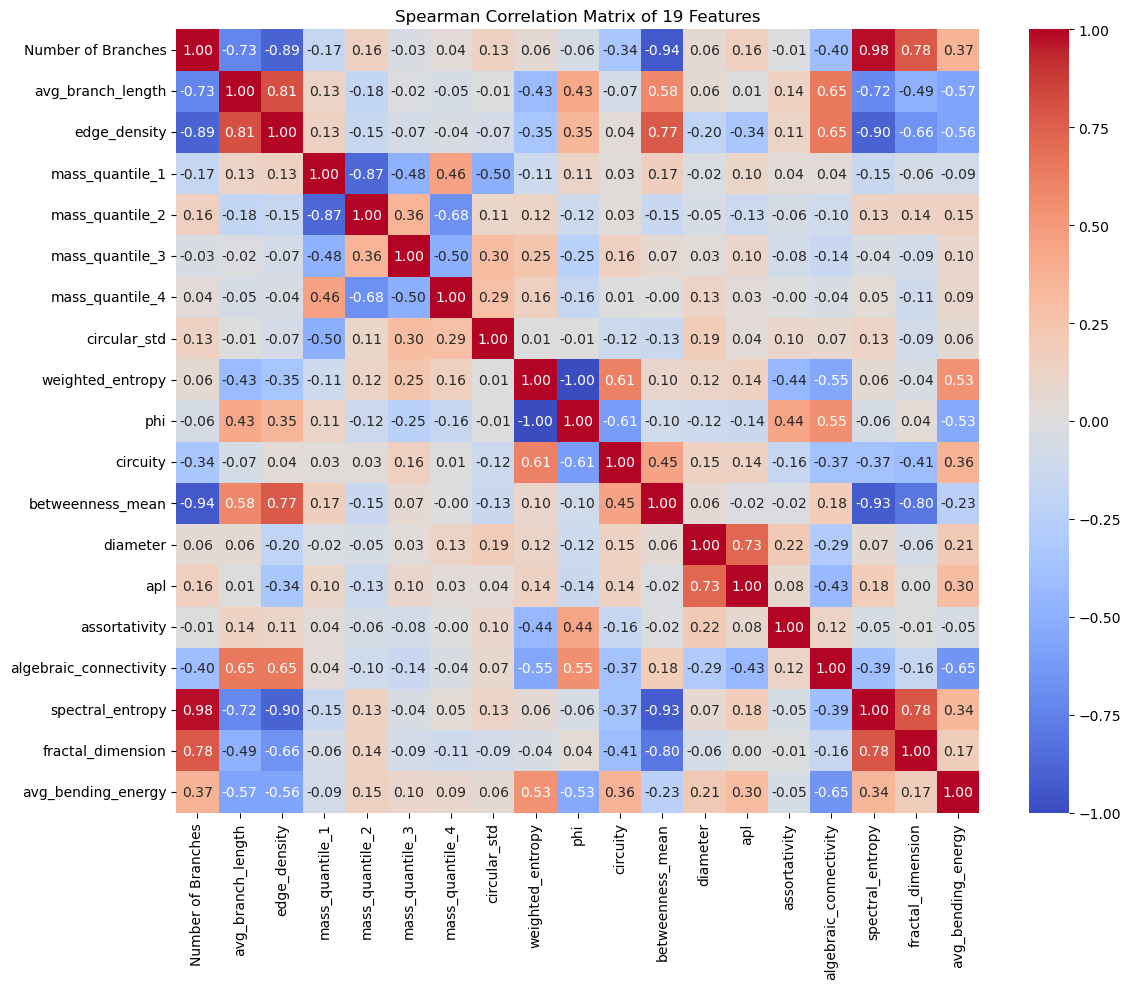

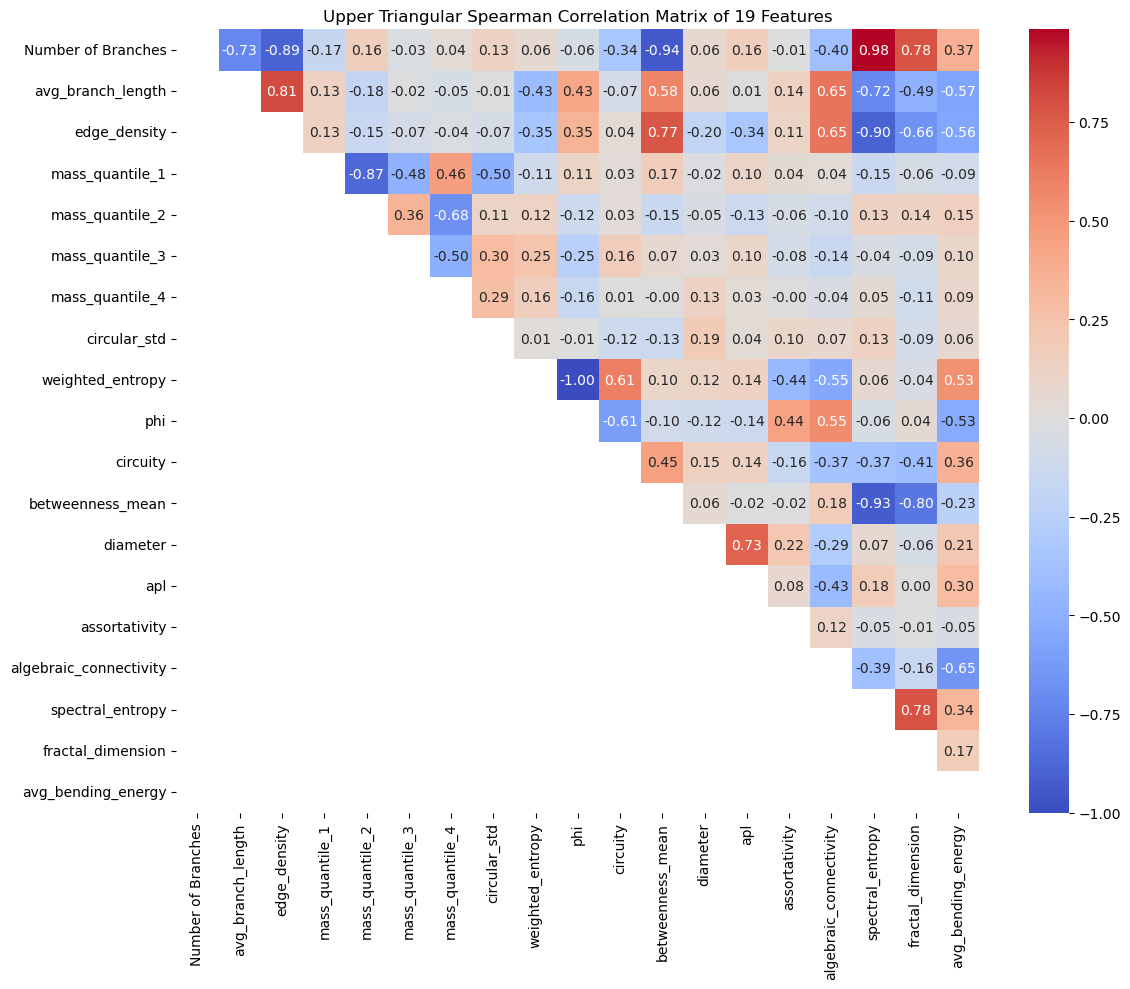

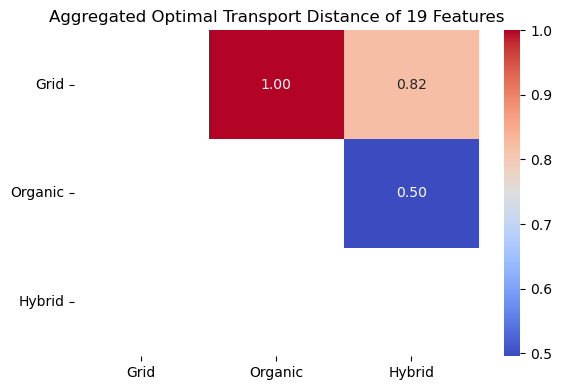

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import spearmanr
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler


df = pd.read_csv('new_road_network_features.csv')

folders = ['grid', 'organic', 'hybrid']

# Add display names for folders
display_folders = ['Grid', 'Organic', 'Hybrid']

# Feature names mapping from CSV columns to internal names
feature_mapping = {
    'number_of_branches': 'Number of Branches',
    'avg_branch_length': 'avg_branch_length',
    'edge_density': 'edge_density',
    'mass_quartile_1': 'mass_quantile_1',
    'mass_quartile_2': 'mass_quantile_2',
    'mass_quartile_3': 'mass_quantile_3',
    'mass_quartile_4': 'mass_quantile_4',
    'circular_std_dev': 'circular_std',
    'weighted_entropy': 'weighted_entropy',
    'orientation_order': 'phi',
    'circuity': 'circuity',
    'mean_betweenness_centrality': 'betweenness_mean',
    'diameter': 'diameter',
    'average_path_length': 'apl',
    'assortativity': 'assortativity',
    'algebraic_connectivity': 'algebraic_connectivity',
    'spectral_entropy': 'spectral_entropy',
    'fractal_dimension': 'fractal_dimension',
    'avg_bending_energy': 'avg_bending_energy'
}

feature_names = list(feature_mapping.values())

# Initialize feature_data
feature_data = {feat: {folder: [] for folder in folders} for feat in feature_names}

# Group by type and populate feature_data
grouped = df.groupby('type')
for group_name, group in grouped:
    folder = group_name.lower()
    if folder in folders:
        for csv_name, feat_name in feature_mapping.items():
            feature_data[feat_name][folder] = group[csv_name].tolist()

# Apply Min-Max normalization to features
scaler = MinMaxScaler()
for feat_name in feature_data.keys():
    # Combine all folder data for this feature
    all_values = []
    for folder in folders:
        all_values.extend(feature_data[feat_name][folder])
    all_values = np.array(all_values)
    # Check if max > 1
    if len(all_values) > 0 and np.max(all_values) > 1:
        all_values_reshaped = all_values.reshape(-1, 1)
        normalized_values = scaler.fit_transform(all_values_reshaped).flatten()
        # Redistribute normalized values back to folders
        start_idx = 0
        for folder in folders:
            num_values = len(feature_data[feat_name][folder])
            feature_data[feat_name][folder] = normalized_values[start_idx:start_idx + num_values].tolist()
            start_idx += num_values

# Compute Spearman correlation matrix
conc_feature_for_corr = []
for folder in folders:
    folder_features = np.array([
        feature_data[feat][folder] for feat in feature_names
    ]).T  # Shape: (n_graphs, 19)
    conc_feature_for_corr.append(folder_features)
conc_feature_for_corr = np.vstack(conc_feature_for_corr)  # Shape: (total_graphs, 19)
corr_matrix = np.zeros((19, 19))
for i in range(19):
    for j in range(19):
        corr_index, _ = spearmanr(conc_feature_for_corr[:, i], conc_feature_for_corr[:, j], nan_policy='omit')
        corr_matrix[i, j] = corr_index if not np.isnan(corr_index) else 0

# Plot full correlation matrix heatmap (upper and lower triangles)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", xticklabels=feature_names, yticklabels=feature_names)
plt.title("Spearman Correlation Matrix of 19 Features")
plt.savefig('Spearman Correlation Matrix of 19 Features.png')
plt.tight_layout()
plt.show()

# Plot upper triangular correlation matrix heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_matrix_upper = np.where(mask, corr_matrix, np.nan)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_upper, annot=True, cmap='coolwarm', fmt=".2f", xticklabels=feature_names, yticklabels=feature_names)
plt.title("Upper Triangular Spearman Correlation Matrix of 19 Features")
plt.tight_layout()
plt.show()

# Upper-triangular function for OT distance
def upper_triangular(df):
    mask = np.triu(np.ones(df.shape), k=1).astype(bool)
    df_upper = df.where(mask)
    return df_upper

# 1D OT distance function
def compute_ot_distance_1d(data1, data2, num_bins=20):
    if not data1 or not data2 or np.any(np.isnan(data1)) or np.any(np.isnan(data2)):
        return np.nan
    min_val = min(np.min(data1), np.min(data2))
    max_val = max(np.max(data1), np.max(data2))
    if min_val == max_val:
        return 0.0
    bins = np.linspace(min_val, max_val, num_bins + 1)
    hist1, _ = np.histogram(data1, bins=bins, density=False)
    hist2, _ = np.histogram(data2, bins=bins, density=False)
    if np.sum(hist1) == 0 or np.sum(hist2) == 0:
        return np.nan
    hist1 = hist1 / np.sum(hist1)
    hist2 = hist2 / np.sum(hist2)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    return wasserstein_distance(bin_centers, bin_centers, hist1, hist2)

# Compute OT distances for each feature
distance_matrix_all_features = np.zeros((19, 3, 3))
for feat_idx, feat_name in enumerate(feature_names):
    for i, folder1 in enumerate(folders):
        for j, folder2 in enumerate(folders):
            data1 = feature_data[feat_name][folder1]
            data2 = feature_data[feat_name][folder2]
            if len(data1) > 0 and len(data2) > 0:
                dist = compute_ot_distance_1d(data1, data2)
                distance_matrix_all_features[feat_idx, i, j] = dist if not np.isnan(dist) else 0

# Aggregated OT distance
I19 = np.eye(19)
tot_distance_matrix = np.zeros((3, 3))
for i in range(19):
    single_feat_distance_matrix = distance_matrix_all_features[i, :, :]
    for k in range(3):
        for l in range(3):
            dist_single_feature = single_feat_distance_matrix[k, l]
            for j in range(i, 19):
                dist_single_feat_vs_rest = distance_matrix_all_features[j, k, l]
                value = I19[i, j] - ((1/19) * np.abs(corr_matrix[i, j] - I19[i, j]))
                tot_distance_matrix[k, l] += dist_single_feature * value * dist_single_feat_vs_rest

# Apply square root transformation (as in original code)
tot_distance_matrix = np.sqrt(tot_distance_matrix)

# Normalize by dividing by the maximum value
tot_distance_matrix /= np.max(tot_distance_matrix)

# Create upper triangular matrix for visualization
df_distances = pd.DataFrame(tot_distance_matrix, index=display_folders, columns=display_folders)
df_distances_upper = upper_triangular(df_distances)

# Plot OT distance heatmap using sns.heatmap
plt.figure(figsize=(6, 4))
ax = sns.heatmap(df_distances_upper, annot=True, cmap='coolwarm', fmt=".2f", mask=df_distances_upper.isnull())

ax.set_yticklabels([lab for lab in display_folders], rotation=0)
plt.title("Aggregated Optimal Transport Distance of 19 Features")
plt.tight_layout()
plt.savefig('ot_distance_heatmap.png', dpi=300)
plt.show()